# Data Cleaning of both users and transactions file

In [1]:
# Importing the libraries
import numpy as np
import pandas as pd

In [2]:
users = pd.read_excel("/content/assignment_users.xlsx")
txns = pd.read_excel("/content/assignment_transactions.xlsx")

In [4]:
users.head()

,user_id,signup_date,signup_channel,city,age,gender,platform,referral_count
0,1001,2025-10-23,social,Kolkata,22.0,F,app,0
1,1002,2026-04-22,ORGANIC,Pune,26.0,female,Web,0
2,1003,2025-06-24,paid-search,Delhi,27.0,F,app,0
3,1004,2025-01-04,paid-search,Pune,34.0,M,app,0
4,1005,2026-01-28,social,Hyderabad,18.0,male,Web,0


# Doing initial analysis of users file

In [5]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         6000 non-null   int64         
 1   signup_date     6000 non-null   datetime64[ns]
 2   signup_channel  6000 non-null   object        
 3   city            5355 non-null   object        
 4   age             5712 non-null   float64       
 5   gender          5333 non-null   object        
 6   platform        6000 non-null   object        
 7   referral_count  6000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 375.1+ KB


In [6]:
users.describe()

,user_id,signup_date,age,referral_count
count,6000.000000,6000,5712.000000,6000.000000
mean,4000.500000,2025-08-19 01:06:57.600000,32.817752,0.143833
min,1001.000000,2024-12-09 00:00:00,0.000000,0.000000
25%,2500.750000,2025-04-13 00:00:00,25.000000,0.000000
50%,4000.500000,2025-08-18 00:00:00,31.000000,0.000000
75%,5500.250000,2025-12-24 00:00:00,36.000000,0.000000
max,7000.000000,2026-05-02 00:00:00,199.000000,4.000000
std,1732.195139,NaN,21.420592,0.398545


In [7]:
# Checking for the null values
users.isnull().sum()

,0
user_id,0
signup_date,0
signup_channel,0
city,645
age,288
gender,667
platform,0
referral_count,0


In [8]:
# checking for the duplicates
users.duplicated().sum()

np.int64(0)

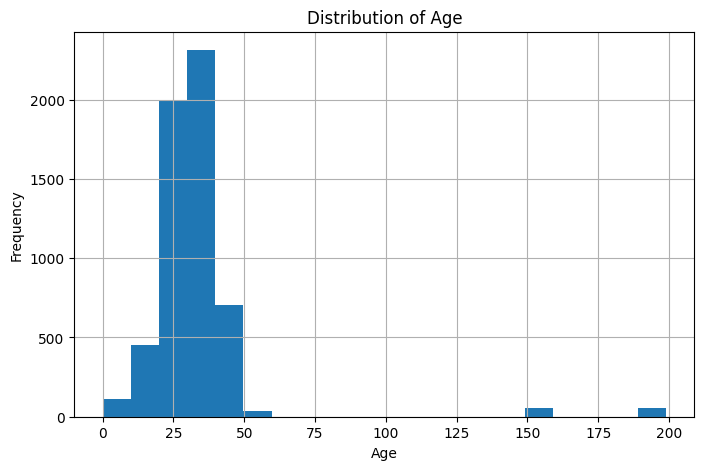

In [9]:
# Seeing the distribution of age column to analyze its distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
users['age'].hist(bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

In [13]:
# replacing the impossible ages to nan
users.loc[
    (users['age'] < 13) |
    (users['age'] > 100),
    'age'
] = np.nan

In [14]:
print("Missing before:", users['age'].isna().sum())
users['age'] = users['age'].fillna(users['age'].median())
print("Missing after:", users['age'].isna().sum())

Missing before: 505
Missing after: 0


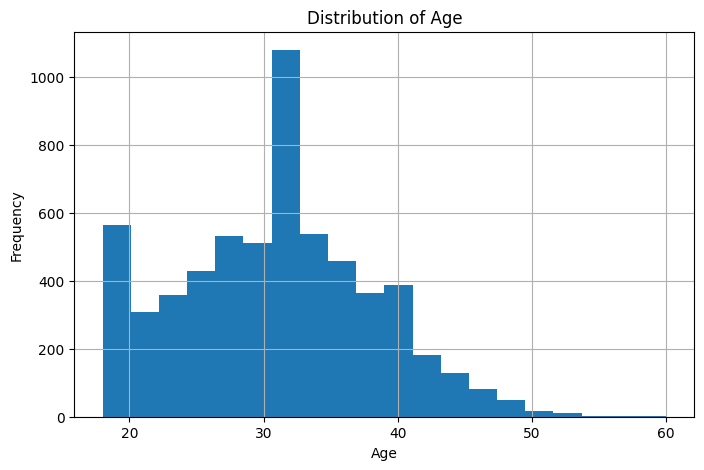

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
users['age'].hist(bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

In [17]:
# Finding the unique cities
users['city'].unique()

array(['Kolkata', 'Pune', 'Delhi', 'Hyderabad', 'Bengaluru', 'Chennai',
       nan, 'Mumbai', 'Lucknow', 'Jaipur', 'Ahmedabad'], dtype=object)

In [19]:
# Filling the not available cities with unknown as filling with mode may increase bias
users['city'] = users['city'].fillna('Unknown')

In [21]:
# Looking into the signup_chhannel
users['signup_channel'].unique()

array(['social', 'ORGANIC', 'paid-search', 'PAID_SEARCH', 'referral',
       'Referral', 'paid_search', 'Social', 'Paid Search', 'organic',
       'affiliate', 'social_media', 'Organic', 'Affiliate', 'REFERRAL'],
      dtype=object)

In [22]:
users['signup_channel'].value_counts(dropna=False)

,count
signup_channel,
Organic,715
organic,672
ORGANIC,650
paid_search,394
PAID_SEARCH,389
paid-search,386
social_media,384
Paid Search,368
social,365


In [23]:
# lowercasing and stripping to bring all of them in same manner and reduce the discrepancies
users['signup_channel'] = (
    users['signup_channel']
    .str.lower()
    .str.strip()
)

In [24]:
# replacing different names of same meaning with same name
users['signup_channel'] = users['signup_channel'].replace({
    'paid-search': 'paid_search',
    'paid search': 'paid_search',
    'social_media': 'social'
})

In [25]:
users['signup_channel'].value_counts()

,count
signup_channel,
organic,2037
paid_search,1537
social,1069
referral,781
affiliate,576


In [26]:
# Same here done for the platform column
users['platform'].value_counts(dropna=False)

,count
platform,
app,2978
web,1039
App,992
Web,991


In [27]:
users['platform'] = (
    users['platform']
    .str.lower()
    .str.strip()
)

In [28]:
users['platform'].value_counts()

,count
platform,
app,3970
web,2030


Same done with the gender column and corrected the gender names and filled the missing rows with unknown to reduce biasness

In [29]:
users['gender'].value_counts(dropna=False)

,count
gender,
F,1370
M,1312
Male,692
female,677
NaN,667
male,643
Female,639


In [30]:
users['gender'] = (
    users['gender']
    .str.lower()
    .str.strip()
)

In [31]:
users['gender'] = users['gender'].replace({
    'm': 'male',
    'male': 'male',
    'f': 'female',
    'female': 'female'
})

In [32]:
users['gender'].value_counts(dropna=False)

,count
gender,
female,2686
male,2647
NaN,667


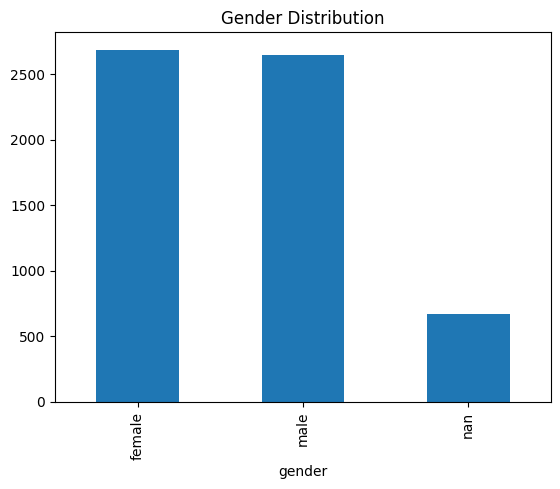

In [33]:
import matplotlib.pyplot as plt

users['gender'].value_counts(dropna=False).plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

In [34]:
users['gender'] = users['gender'].fillna('unknown')

In [35]:
users['gender'].isna().sum()

np.int64(0)

check the data type of the signup date and there it's distribution on the month basis

In [36]:
users['signup_date'].dtype

dtype('<M8[ns]')

In [37]:
print("Missing:", users['signup_date'].isna().sum())
print("Earliest:", users['signup_date'].min())
print("Latest:", users['signup_date'].max())

Missing: 0
Earliest: 2024-12-09 00:00:00
Latest: 2026-05-02 00:00:00


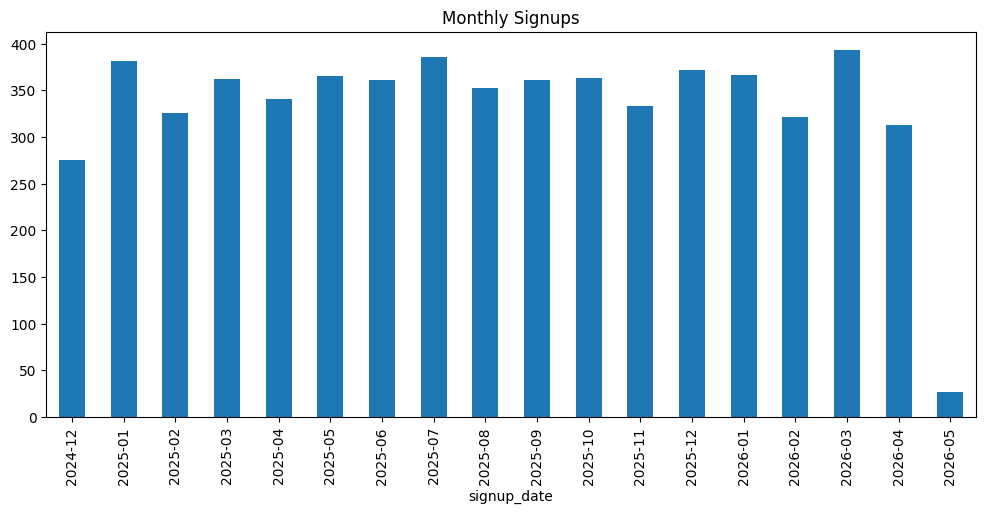

In [38]:
users['signup_date'].dt.to_period('M').value_counts().sort_index().plot(
    kind='bar',
    figsize=(12,5)
)
plt.title("Monthly Signups")
plt.show()

In [39]:
users['referral_count'].value_counts().sort_index()

,count
referral_count,
0,5233
1,681
2,77
3,8
4,1


In [42]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         6000 non-null   int64         
 1   signup_date     6000 non-null   datetime64[ns]
 2   signup_channel  6000 non-null   object        
 3   city            6000 non-null   object        
 4   age             6000 non-null   float64       
 5   gender          6000 non-null   object        
 6   platform        6000 non-null   object        
 7   referral_count  6000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 375.1+ KB


# Saving the cleaned users file as cleaned_users

In [40]:
users.to_excel("cleaned_users.xlsx", index=False)

# Now moving towards the transaction file
Initial analysis

In [43]:
txns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28941 entries, 0 to 28940
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   txn_id           28941 non-null  int64         
 1   user_id          28941 non-null  int64         
 2   txn_date         28941 non-null  datetime64[ns]
 3   retailer         28941 non-null  object        
 4   order_value      28941 non-null  float64       
 5   cashback_earned  28941 non-null  float64       
 6   cashback_status  28941 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 1.5+ MB


In [44]:
txns.duplicated().sum()

np.int64(287)

In [45]:
# Checking the duplicates
print("Unique txn_ids:", txns['txn_id'].nunique())
print("Total rows:", len(txns))

Unique txn_ids: 28654
Total rows: 28941


In [46]:
# Checking the range of the transaction dates
print("Earliest:", txns['txn_date'].min())
print("Latest:", txns['txn_date'].max())

Earliest: 2024-12-11 00:00:00
Latest: 2026-05-31 00:00:00


In [48]:
duplicate_rows = txns[txns.duplicated()]

duplicate_rows

,txn_id,user_id,txn_date,retailer,order_value,cashback_earned,cashback_status
1627,12758,3697,2026-04-07,Mamaearth,1469.07,27.33,confirmed
2614,10989,3304,2026-04-05,Tata CLiQ,856.23,63.52,pending
3777,15333,4192,2026-04-03,Tata CLiQ,1531.89,82.50,pending
4177,22266,5658,2026-01-27,MakeMyTrip,1338.75,37.20,pending
4229,9831,3070,2025-06-26,FirstCry,1677.60,113.56,confirmed
...,...,...,...,...,...,...,...
28762,2795,1602,2026-03-29,FirstCry,1571.91,95.38,confirmed
28813,5791,2212,2025-10-29,Croma,660.90,29.43,rejected
28883,27384,6743,2025-12-31,MakeMyTrip,731.98,29.55,confirmed
28891,18457,4860,2025-07-17,MakeMyTrip,576.11,27.68,confirmed


In [49]:
# Dropping the duplicated txns
txns = txns.drop_duplicates()

In [50]:
txns.duplicated().sum()

np.int64(0)

In [51]:
txns.shape

(28654, 7)

In [52]:
# Checking the number of the cashback status
txns['cashback_status'].value_counts(dropna=False)

,count
cashback_status,
confirmed,17803
pending,7461
rejected,3390


In [54]:
txns['retailer'].unique()

array(['Ajio', 'MakeMyTrip', 'Flipkart', 'Amazon', 'Boat', 'Swiggy',
       'Nykaa', 'Tata CLiQ', 'Mamaearth', 'Croma', 'FirstCry', 'Myntra'],
      dtype=object)

In [55]:
txns['order_value'].describe()

,order_value
count,28654.000000
mean,1361.784049
std,1576.013744
min,-22206.140000
25%,582.207500
50%,1041.785000
75%,1815.555000
max,46890.860000


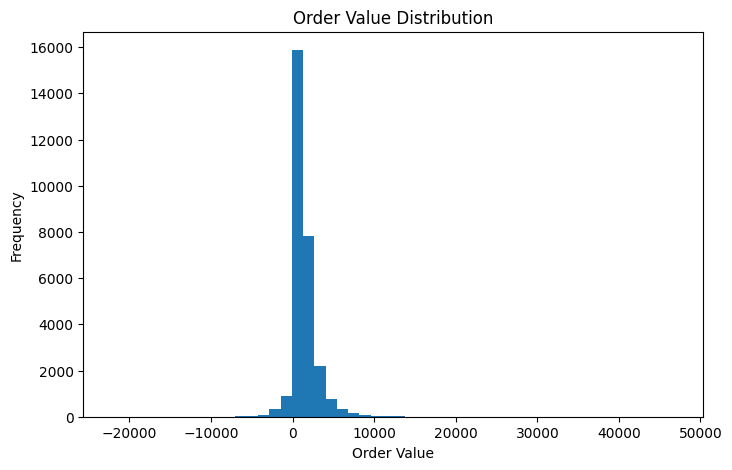

In [57]:
# Plotting the distribution of the Order Value
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(txns['order_value'], bins=50)
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.title("Order Value Distribution")
plt.show()

In [58]:
# negative transactions most likely the returned values
(txns['order_value'] < 0).sum()

np.int64(1367)

In [59]:
txns[txns['order_value'] < 0].head(50)

,txn_id,user_id,txn_date,retailer,order_value,cashback_earned,cashback_status
2,20053,5198,2025-09-21,MakeMyTrip,-327.65,0.0,confirmed
70,10820,3270,2025-10-14,Croma,-1078.12,0.0,rejected
92,10375,3179,2026-05-19,Flipkart,-1735.53,0.0,confirmed
109,7028,2466,2026-01-23,Flipkart,-427.94,0.0,rejected
118,21715,5542,2025-07-20,Ajio,-3755.83,0.0,confirmed
135,25382,6331,2026-04-15,Swiggy,-257.84,0.0,pending
147,18650,4906,2026-05-15,Myntra,-1082.74,0.0,pending
169,25044,6255,2025-12-25,Myntra,-1179.35,0.0,pending
174,17432,4647,2026-04-17,Mamaearth,-2017.01,0.0,confirmed
182,10327,3173,2025-11-28,Nykaa,-1330.31,0.0,pending


In [60]:
txns[txns['order_value'] < 0].describe()

,txn_id,user_id,txn_date,order_value,cashback_earned
count,1367.000000,1367.000000,1367,1367.000000,1367.0
mean,14684.021214,4079.692758,2025-12-24 01:28:29.144111360,-1532.485311,0.0
min,4.000000,1003.000000,2024-12-23 00:00:00,-22206.140000,0.0
25%,7525.000000,2569.500000,2025-10-01 12:00:00,-1903.515000,0.0
50%,14871.000000,4105.000000,2026-01-24 00:00:00,-1109.520000,0.0
75%,21830.000000,5564.000000,2026-04-11 00:00:00,-634.945000,0.0
max,28635.000000,6993.000000,2026-05-31 00:00:00,-73.490000,0.0
std,8305.538309,1737.283030,NaN,1560.256989,0.0


In [62]:
# checking is the cashback earned is genuine as it should not be > order value except the returned ones
(txns['cashback_earned'] > txns['order_value']).sum()

np.int64(1367)

In [63]:
txns['cashback_earned'].describe()

,cashback_earned
count,28654.000000
mean,64.511845
std,76.794328
min,0.000000
25%,20.050000
50%,42.025000
75%,81.535000
max,2813.000000


In [65]:
# positive transactions cashback rate
positive_txns = txns[txns['order_value'] > 0].copy()

positive_txns['cashback_rate'] = (
    positive_txns['cashback_earned']
    /
    positive_txns['order_value']
)

In [66]:
positive_txns['cashback_rate'].describe()

,cashback_rate
count,27287.000000
mean,0.045026
std,0.020162
min,0.010001
25%,0.027582
50%,0.045049
75%,0.062479
max,0.079993


In [67]:
# saving the cleaned transaction file to cleaned_transactions
txns.to_excel("cleaned_transactions.xlsx", index=False)